# Анализ датасета фильмов (TMDB)

Мини-проект: очистка данных и анализ датасета из ~10 000 фильмов.

**Цель:** привести таблицу к чистому виду и найти интересные закономерности — что влияет на рейтинг и популярность фильмов.

**Данные:** id, название, популярность, язык оригинала, описание, дата выхода, средний рейтинг, число голосов.


## 1. Загрузка данных

In [1]:
import pandas as pd

df = pd.read_csv('moviesTMBD.csv')
df.head()

   Unnamed: 0       id                     title  popularity  adult original_language                                                                                                                                                                                                                                                                                                                                                                                                  overview release_date  vote_average  vote_count
0           0  1007757                   Swapped    327.5134  False                en                                                                                               A small woodland creature and a majestic bird, two natural sworn enemies of the Valley, magically trade places and set off on an adventure of a lifetime to switch back. Their journey soon uncovers a greater threat—one that could endanger not only their species, but the entire valley they call home.  

In [2]:
df.shape

(9980, 10)

In [3]:
df.dtypes

Unnamed: 0             int64
id                     int64
title                    str
popularity           float64
adult                   bool
original_language        str
overview                 str
release_date             str
vote_average         float64
vote_count             int64

In [4]:
df.isnull().sum()  # проверяем пропущенные значения

Unnamed: 0           0
id                   0
title                0
popularity           0
adult                0
original_language    0
overview             2
release_date         2
vote_average         0
vote_count           0

**Что видим:**
- 9980 строк, 10 колонок
- Колонка `Unnamed: 0` — лишний индекс, сохранившийся при экспорте, её нужно убрать
- Пропуски есть только в `overview` и `release_date` (по 2 строки) — мало, можно просто удалить эти строки


## 2. Очистка данных

In [5]:
# Убираем лишнюю колонку-индекс
df = df.drop(columns=['Unnamed: 0'])

# Убираем строки с пропусками в описании и дате выхода
df = df.dropna(subset=['overview', 'release_date'])

df.shape

(9977, 9)

In [ ]:
# Проверяем дубликаты по уникальному id
# (по названию лучше этого не делать, т.к. у разных фильмов может быть одинаковое название - ремейки)
df.duplicated(subset='id').sum()

554

In [7]:
# Удаляем настоящие дубликаты (по id), оставляя первую запись
df = df.drop_duplicates(subset='id', keep='first')

# Приводим дату к формату datetime, чтобы удобно доставать год/месяц
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

df.shape

(9423, 9)

In [8]:
df.to_csv('movies_clean.csv', index=False)

**Итог очистки:**

| Шаг | Строк осталось |
|---|---|
| Исходный файл | 9980 |
| Убрали пропуски | 9977 |
| Убрали дубликаты по id | **9423** |

Убрано **554 дубликата** — записи, где один и тот же фильм (тот же `id`) случайно продублирован в файле.


## 3. Анализ данных

### 3.1. Топ-10 фильмов по рейтингу

In [9]:
df.sort_values('vote_average', ascending=False).head(10)[['title','vote_average','vote_count','release_date']]

                      title  vote_average  vote_count release_date
                    Swapped         8.987        1320   2026-05-01
   The Shawshank Redemption         8.721       30387   1994-09-23
              The Godfather         8.686       22929   1972-03-14
          Project Hail Mary         8.621        3950   2026-03-15
               12 Angry Men         8.600        9977   1957-04-10
      The Godfather Part II         8.571       13901   1974-12-20
           Schindler's List         8.569       17447   1993-12-15
Remarkably Bright Creatures         8.546         393   2026-05-07
              Spirited Away         8.534       18302   2001-07-20
            The Dark Knight         8.530       35750   2008-07-16

### 3.2. Языки фильмов — сколько и на каком языке

In [10]:
df['original_language'].value_counts()

original_language
en    7278
fr     630
it     345
ja     291
es     189
de     105
ko      99
cn      67
zh      63
ru      52
hi      44
sv      38
da      33
pt      32
no      29
pl      19
th      13
nl      13
tr      11
fa      11
fi       9
id       7
hu       6
el       4
ar       3
sr       3
te       3
uk       3
cs       3
xx       2
ro       2
hy       2
is       2
eu       2
lv       1
bn       1
sh       1
ga       1
bs       1
ml       1
la       1
tn       1
he       1
mk       1

Английский язык доминирует (~77% фильмов) — ожидаемо для международной базы вроде TMDB.

### 3.3. Средний рейтинг по языкам (только языки с ≥50 фильмами, чтобы не ловить случайность)

In [11]:
lang_counts = df['original_language'].value_counts()
popular_langs = lang_counts[lang_counts >= 50].index

df[df['original_language'].isin(popular_langs)]\
    .groupby('original_language')['vote_average'].mean()\
    .sort_values(ascending=False)

original_language
ja    7.360031
ko    7.311869
zh    7.150016
de    7.076267
cn    7.064672
ru    7.034346
es    7.024852
it    6.885501
fr    6.814879
en    6.674818

**Вывод:** нашли интересную закономерность — фильмы **не на английском** языке (японский, корейский, китайский, немецкий и др.) в среднем оцениваются **выше** (6.8–7.4), чем англоязычные (6.67), несмотря на то что английских фильмов в разы больше (7278 против 50-300 у остальных).

**Почему так могло произойти:** в международную базу вроде TMDB попадает практически любой англоязычный фильм, включая проходные и слабые. А фильм на японском/корейском/русском получает известность и много голосов на международном уровне, только если он действительно качественный — слабые локальные фильмы просто не доходят до глобальной аудитории.


### 3.4. Распределение рейтингов фильмов

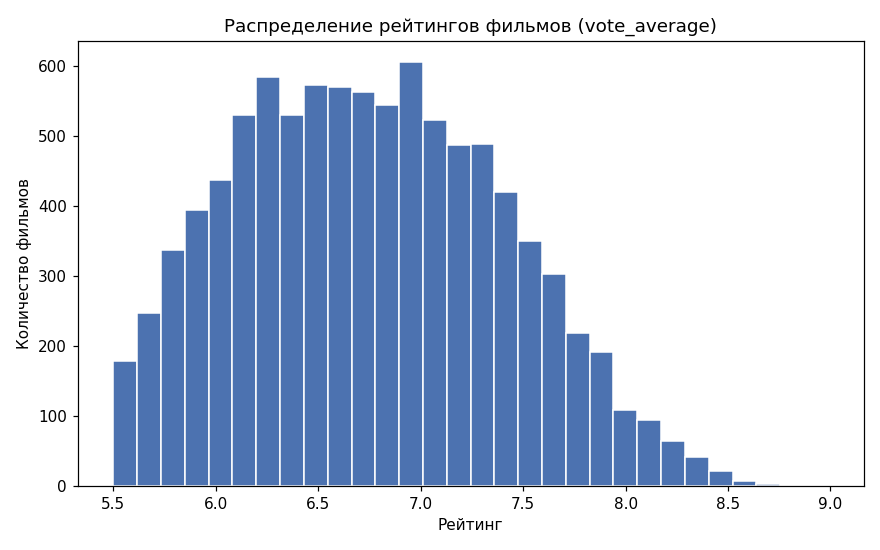

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['vote_average'], bins=30, color='#4C72B0', edgecolor='white')
plt.title('Распределение рейтингов фильмов (vote_average)')
plt.xlabel('Рейтинг')
plt.ylabel('Количество фильмов')
plt.tight_layout()
plt.show()

**Наблюдение:** основная масса фильмов держится в диапазоне 6.3–7.5. Медиана — 6.72. Фильмов с рейтингом 8+ заметно меньше — попасть в топ сложно.

### 3.5. Связь популярности и рейтинга

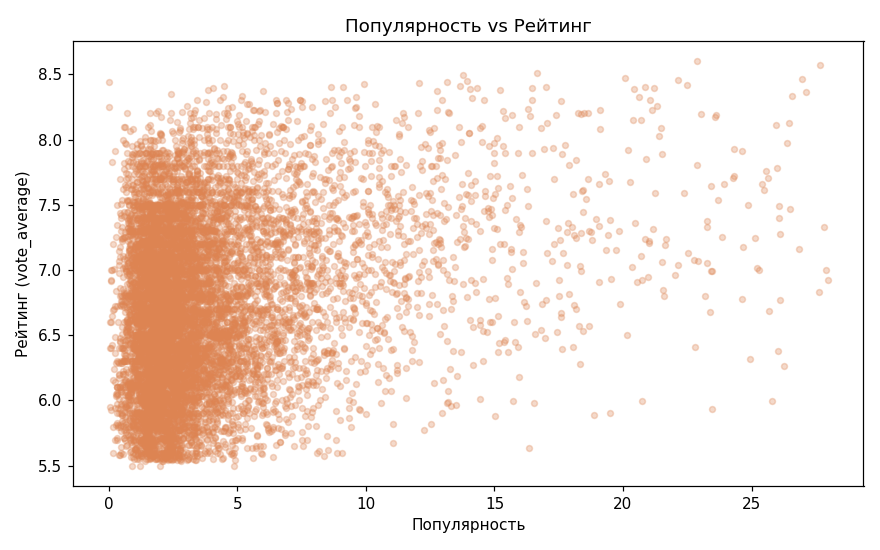

0.178

In [13]:
df_plot = df[df['popularity'] < df['popularity'].quantile(0.99)]

plt.figure(figsize=(8,5))
plt.scatter(df_plot['popularity'], df_plot['vote_average'], alpha=0.3, s=15, color='#DD8452')
plt.title('Популярность vs Рейтинг')
plt.xlabel('Популярность')
plt.ylabel('Рейтинг (vote_average)')
plt.tight_layout()
plt.show()

df['popularity'].corr(df['vote_average'])

**Вывод:** корреляция слабая (0.178 по шкале от -1 до 1) — популярность фильма почти не связана с его рейтингом. `popularity` в TMDB отражает текущий хайп (свежие релизы, тренды), а не реальное качество фильма.

### 3.6. Как менялся средний рейтинг по годам

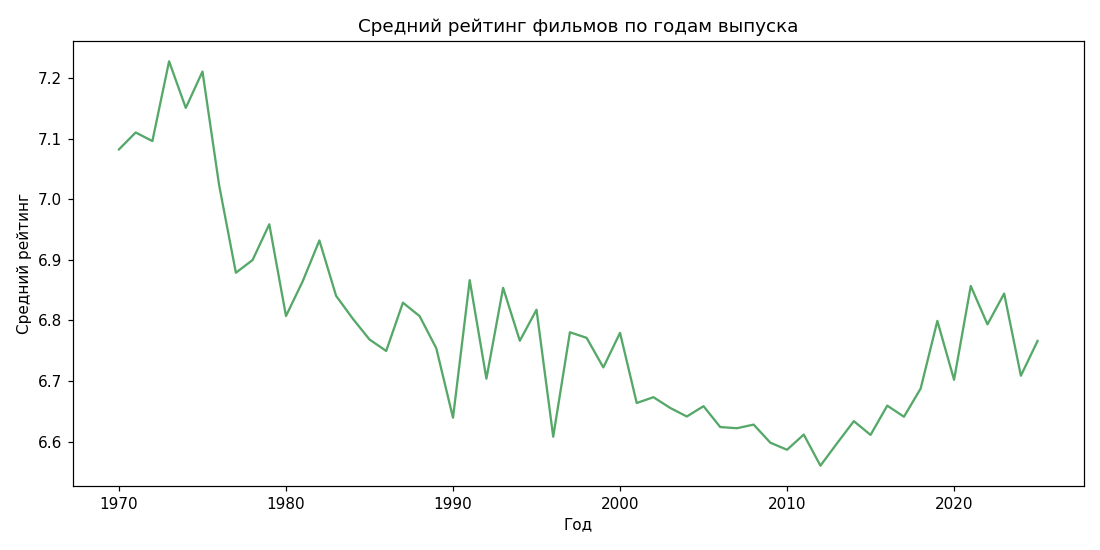

In [14]:
df['year'] = df['release_date'].dt.year
by_year = df.groupby('year')['vote_average'].mean()
by_year = by_year[(by_year.index >= 1970) & (by_year.index <= 2025)]

plt.figure(figsize=(10,5))
plt.plot(by_year.index, by_year.values, color='#55A868')
plt.title('Средний рейтинг фильмов по годам выпуска')
plt.xlabel('Год')
plt.ylabel('Средний рейтинг')
plt.tight_layout()
plt.show()

**Вывод:** средний рейтинг фильмов держится стабильно в районе 6.6–6.9 на протяжении последних десятилетий, без выраженного тренда роста или падения.

## 4. Итоговые выводы

1. **Качество данных:** исходный датасет содержал 554 полных дубликата записей (по `id`) — их важно было находить именно по уникальному идентификатору, а не по названию, так как у разных фильмов (ремейков) названия могут совпадать.
2. **Популярность и качество - не одно и то же.** Корреляция между `popularity` и `vote_average` слабая (около 0.18). Популярность отражает текущий хайп, а не реальную оценку фильма.
3. **Языковой стереотип.** Фильмы не на английском языке (японские, корейские, китайские и др.) в среднем оцениваются выше английских — вероятно, из-за более строгого отбора при попадании в международную базу.
4. **Стабильность во времени.** Средний рейтинг фильмов не показывает выраженного тренда роста/падения за последние десятилетия.

